In [ ]:
df = pd.read_csv("daily-demand-series.csv")

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [ ]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

NameError: name 'pd' is not defined

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (30, 4)

Column Names:
Index(['date', 'demand', 'marketing_event', 'holiday'], dtype='object')

Data Types:
date               object
demand              int64
marketing_event     int64
holiday             int64
dtype: object

Missing Values:
date               0
demand             0
marketing_event    0
holiday            0
dtype: int64


In [ ]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [ ]:
df.set_index("date", inplace=True)

df.head()

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


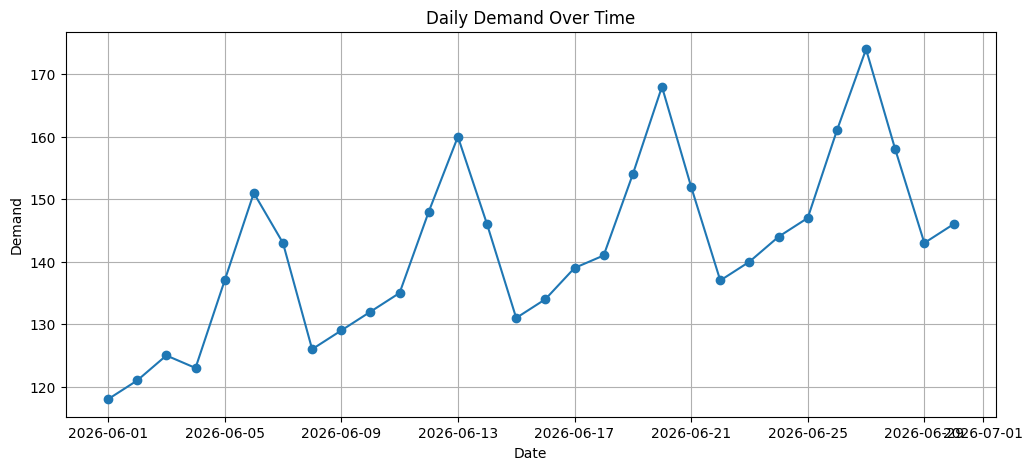

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["demand"], marker="o")

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

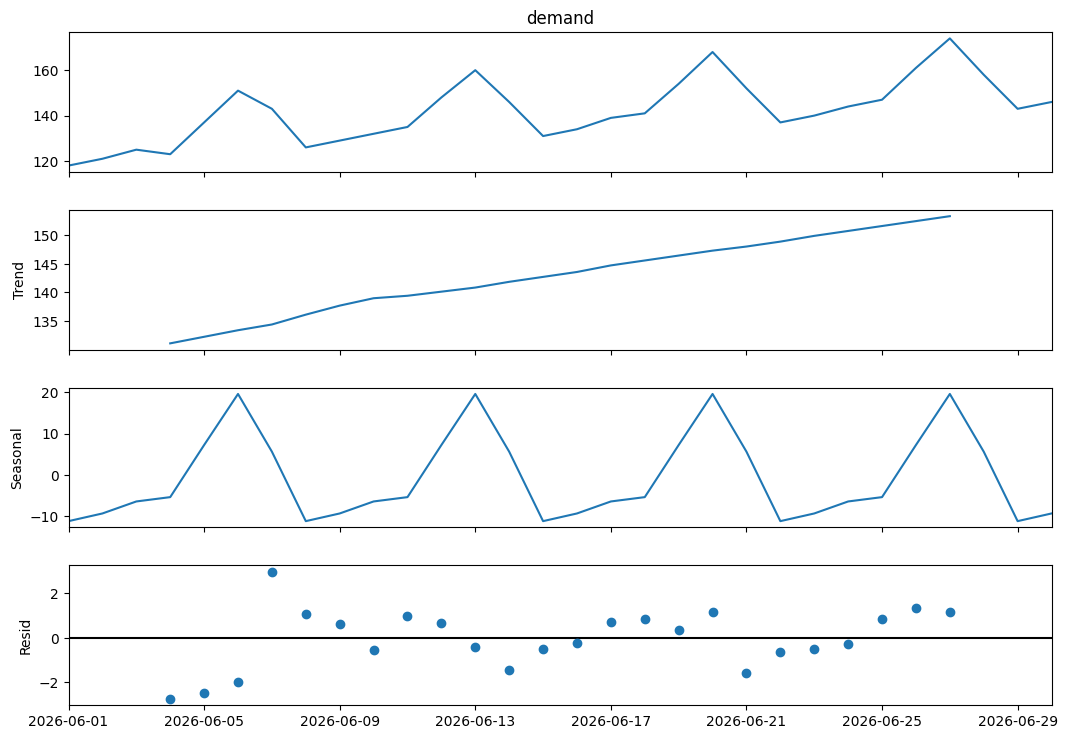

In [ ]:
decomposition = seasonal_decompose(
    df["demand"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["demand"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.9038698873856339
p-value: 0.7866953368372341


/tmp/ipykernel_1599/1913927614.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df["demand"])


In [ ]:
df["demand_diff"] = df["demand"].diff()

df["demand_diff"].head()

,demand_diff
date,
2026-06-01,NaN
2026-06-02,3.0
2026-06-03,4.0
2026-06-04,-2.0
2026-06-05,14.0


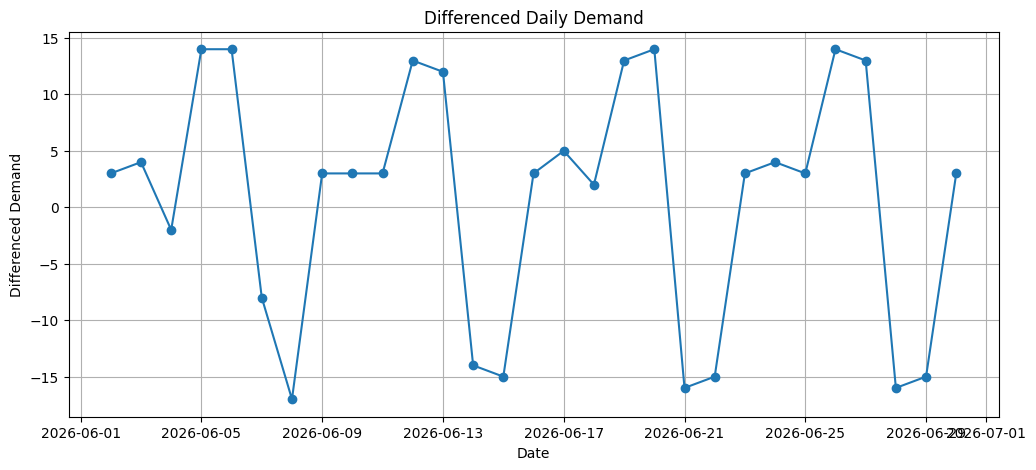

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["demand_diff"], marker="o")

plt.title("Differenced Daily Demand")
plt.xlabel("Date")
plt.ylabel("Differenced Demand")

plt.grid(True)
plt.show()

In [ ]:
diff_data = df["demand_diff"].dropna()

result_diff = adfuller(diff_data)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -2.233624012735415
p-value: 0.19426893706635578


/tmp/ipykernel_1599/2133146180.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff = adfuller(diff_data)


In [ ]:
df["demand_diff2"] = df["demand_diff"].diff()

df["demand_diff2"].head()

,demand_diff2
date,
2026-06-01,NaN
2026-06-02,NaN
2026-06-03,1.0
2026-06-04,-6.0
2026-06-05,16.0


In [ ]:
second_diff_data = df["demand_diff2"].dropna()

result_diff2 = adfuller(second_diff_data)

print("ADF Statistic:", result_diff2[0])
print("p-value:", result_diff2[1])

ADF Statistic: -15.186988638006405
p-value: 6.085057742439692e-28


/tmp/ipykernel_1599/3581492776.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff2 = adfuller(second_diff_data)


In [ ]:
series = df["demand"]

train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Total observations:", len(series))
print("Training observations:", len(train))
print("Testing observations:", len(test))

Total observations: 30
Training observations: 24
Testing observations: 6


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
model = ARIMA(train, order=(1, 2, 1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                   24
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -86.011
Date:                Wed, 23 Sep 2026   AIC                            178.022
Time:                        16:12:43   BIC                            181.295
Sample:                    06-01-2026   HQIC                           178.793
                         - 06-24-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4160      0.449     -0.927      0.354      -1.295       0.463
ma.L1          0.7967      0.271      2.943      0.003       0.266       1.327
sigma2       143.0853     47.699      3.000      0.0

In [ ]:
forecast = model_fit.forecast(steps=len(test))

print("Forecasted Values:")
print(forecast)

Forecasted Values:
2026-06-25    147.469242
2026-06-26    151.159280
2026-06-27    154.757466
2026-06-28    158.393863
2026-06-29    162.014364
2026-06-30    165.641478
Freq: D, Name: predicted_mean, dtype: float64


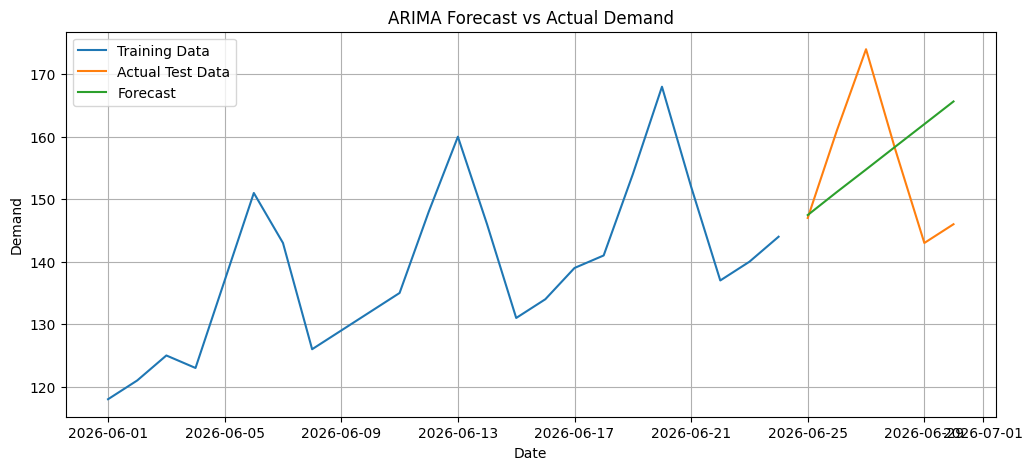

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test, forecast) * 100

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAPE:", round(mape, 2), "%")
print("RMSE:", round(rmse, 2))

MAPE: 7.41 %
RMSE: 14.23


In [ ]:
final_model = ARIMA(series, order=(1, 2, 1))

final_model_fit = final_model.fit()

print("Final ARIMA model fitted successfully!")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Final ARIMA model fitted successfully!


In [ ]:
future_forecast = final_model_fit.forecast(steps=30)

print("30-Day Forecast:")
print(future_forecast)

30-Day Forecast:
2026-07-01    150.076574
2026-07-02    153.698541
2026-07-03    157.512476
2026-07-04    161.245348
2026-07-05    165.012451
2026-07-06    168.765099
2026-07-07    172.523850
2026-07-08    176.280025
2026-07-09    180.037288
2026-07-10    183.794091
2026-07-11    187.551088
2026-07-12    191.308003
2026-07-13    195.064953
2026-07-14    198.821888
2026-07-15    202.578830
2026-07-16    206.335769
2026-07-17    210.092708
2026-07-18    213.849648
2026-07-19    217.606588
2026-07-20    221.363527
2026-07-21    225.120467
2026-07-22    228.877406
2026-07-23    232.634346
2026-07-24    236.391286
2026-07-25    240.148225
2026-07-26    243.905165
2026-07-27    247.662104
2026-07-28    251.419044
2026-07-29    255.175984
2026-07-30    258.932923
Freq: D, Name: predicted_mean, dtype: float64


In [ ]:
future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

print("Future Dates:")
print(future_dates)

Future Dates:
DatetimeIndex(['2026-07-01', '2026-07-02', '2026-07-03', '2026-07-04',
               '2026-07-05', '2026-07-06', '2026-07-07', '2026-07-08',
               '2026-07-09', '2026-07-10', '2026-07-11', '2026-07-12',
               '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16',
               '2026-07-17', '2026-07-18', '2026-07-19', '2026-07-20',
               '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
               '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28',
               '2026-07-29', '2026-07-30'],
              dtype='datetime64[ns]', freq='D')


In [ ]:
forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast_demand": future_forecast.values
})

forecast_df

,date,forecast_demand
0,2026-07-01,150.076574
1,2026-07-02,153.698541
2,2026-07-03,157.512476
3,2026-07-04,161.245348
4,2026-07-05,165.012451
5,2026-07-06,168.765099
6,2026-07-07,172.523850
7,2026-07-08,176.280025
8,2026-07-09,180.037288
9,2026-07-10,183.794091


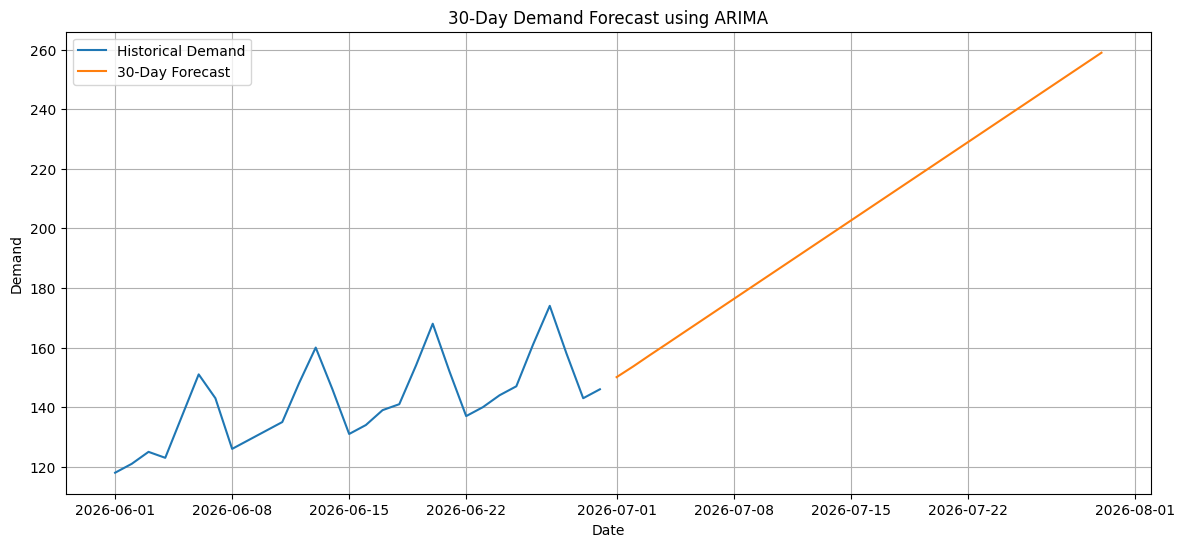

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    series.index,
    series.values,
    label="Historical Demand"
)

plt.plot(
    future_dates,
    future_forecast,
    label="30-Day Forecast"
)

plt.title("30-Day Demand Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()
plt.grid(True)

plt.show()

# Conclusion

In this project, daily demand data was analyzed using time-series forecasting techniques.

The time series was first visualized and decomposed into observed, trend, seasonal, and residual components. The Augmented Dickey-Fuller (ADF) test was then performed to check stationarity.

The original time series was found to be non-stationary with an ADF p-value of 0.7867. First differencing was performed, but the series remained non-stationary with a p-value of 0.1943. After second differencing, the series became stationary with a p-value of approximately 6.09 × 10⁻⁹.

An ARIMA(1,2,1) model was trained using the demand data. The model was evaluated using Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE).

The model achieved:

- MAPE: 7.41%
- RMSE: 14.23

Finally, the trained ARIMA model was used to generate a 30-day future demand forecast.

Overall, the project demonstrates how ARIMA-based time-series forecasting can be used to analyze historical demand patterns and predict future demand for planning and decision-making.

✅ Dataset loaded successfully!
✅ Date converted successfully!
✅ Date set as index successfully!

Dataset shape: (30, 3)

Columns: ['demand', 'marketing_event', 'holiday']


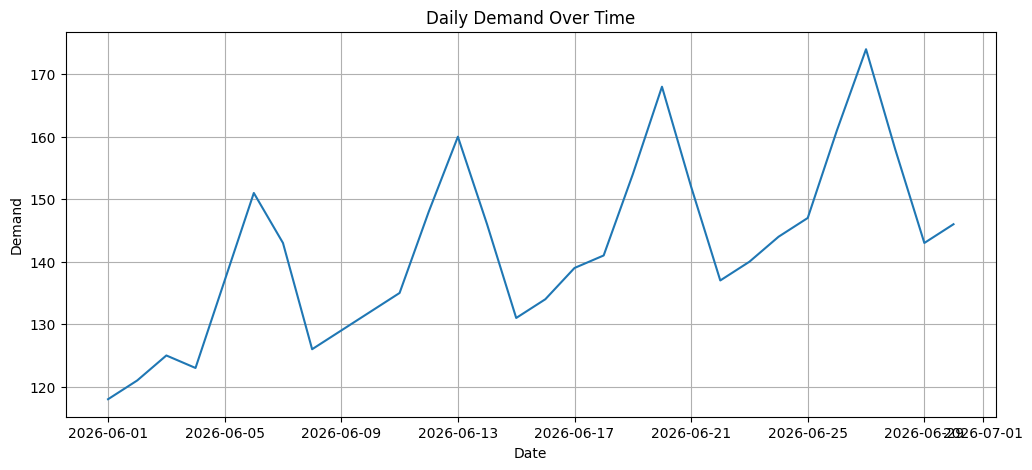

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # Load dataset again safely
    df = pd.read_csv("daily-demand-series.csv")

    # Check required columns
    if "date" not in df.columns:
        print("❌ 'date' column not found.")
    elif "demand" not in df.columns:
        print("❌ 'demand' column not found.")
    else:
        # Convert date safely
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

        # Remove invalid dates
        df = df.dropna(subset=["date"])

        # Sort by date
        df = df.sort_values("date")

        # Set date as index
        df = df.set_index("date")

        print("✅ Dataset loaded successfully!")
        print("✅ Date converted successfully!")
        print("✅ Date set as index successfully!")
        print("\nDataset shape:", df.shape)
        print("\nColumns:", list(df.columns))

        # Plot demand
        plt.figure(figsize=(12, 5))
        plt.plot(df.index, df["demand"])
        plt.title("Daily Demand Over Time")
        plt.xlabel("Date")
        plt.ylabel("Demand")
        plt.grid(True)
        plt.show()

except FileNotFoundError:
    print("❌ CSV file not found.")
    print("Please make sure 'daily-demand-series.csv' is uploaded in Colab.")

except Exception as e:
    print("❌ An error occurred:")
    print(type(e).__name__, ":", e)

In [ ]:
# Descriptive statistics for demand

try:
    if "demand" not in df.columns:
        print("❌ Demand column not found.")
    else:
        print("✅ Descriptive Statistics of Daily Demand\n")
        print(df["demand"].describe())

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ Descriptive Statistics of Daily Demand

count     30.000000
mean     142.100000
std       13.839848
min      118.000000
25%      132.500000
50%      142.000000
75%      150.250000
max      174.000000
Name: demand, dtype: float64


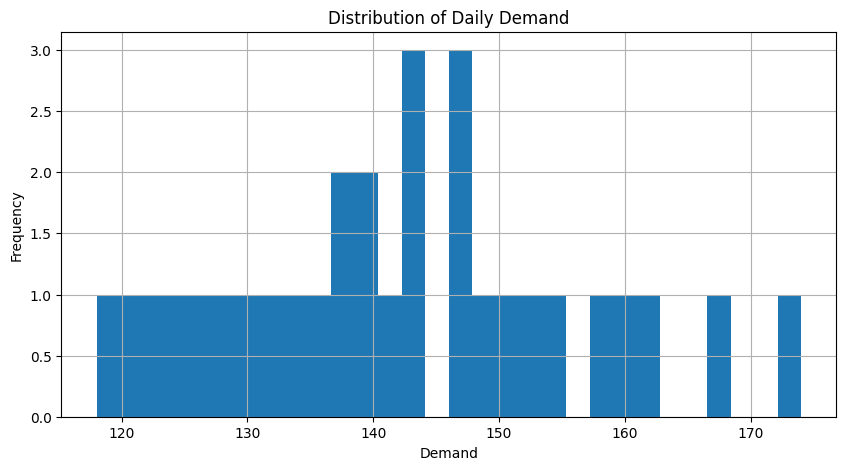

✅ Demand distribution graph created successfully.


In [ ]:
# Demand Distribution

try:
    if "demand" not in df.columns:
        print("❌ Demand column not found.")
    else:
        demand_data = pd.to_numeric(df["demand"], errors="coerce").dropna()

        if len(demand_data) == 0:
            print("❌ No valid demand values found.")
        else:
            plt.figure(figsize=(10, 5))
            plt.hist(demand_data, bins=30)
            plt.title("Distribution of Daily Demand")
            plt.xlabel("Demand")
            plt.ylabel("Frequency")
            plt.grid(True)
            plt.show()

            print("✅ Demand distribution graph created successfully.")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

In [ ]:
# Marketing Event vs Average Demand

try:
    if "marketing_event" not in df.columns:
        print("❌ 'marketing_event' column not found.")
    elif "demand" not in df.columns:
        print("❌ 'demand' column not found.")
    else:
        result = df.groupby("marketing_event")["demand"].mean()

        print("✅ Average Demand by Marketing Event:\n")
        print(result)

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ Average Demand by Marketing Event:

marketing_event
0    136.818182
1    156.625000
Name: demand, dtype: float64


In [ ]:
# Holiday vs Average Demand

try:
    if "holiday" not in df.columns:
        print("❌ 'holiday' column not found.")
    elif "demand" not in df.columns:
        print("❌ 'demand' column not found.")
    else:
        result = df.groupby("holiday")["demand"].mean()

        print("✅ Average Demand by Holiday Status:\n")
        print(result)

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ Average Demand by Holiday Status:

holiday
0    140.923077
1    149.750000
Name: demand, dtype: float64


In [ ]:
# ADF Test - Original Demand Series

try:
    from statsmodels.tsa.stattools import adfuller
    import pandas as pd

    if "demand" not in df.columns:
        print("❌ Demand column not found.")
    else:
        demand = pd.to_numeric(df["demand"], errors="coerce").dropna()

        if len(demand) < 10:
            print("❌ Not enough data for ADF test.")
        else:
            result = adfuller(demand)

            print("✅ ADF Test - Original Demand")
            print("--------------------------------")
            print("ADF Statistic :", result[0])
            print("p-value       :", result[1])

            if result[1] < 0.05:
                print("Conclusion    : Stationary")
            else:
                print("Conclusion    : Non-stationary")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ ADF Test - Original Demand
--------------------------------
ADF Statistic : -0.9038698873856339
p-value       : 0.7866953368372341
Conclusion    : Non-stationary


/tmp/ipykernel_909/710460707.py:15: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(demand)


In [ ]:
# First Differencing + ADF Test

try:
    from statsmodels.tsa.stattools import adfuller

    if "demand" not in df.columns:
        print("❌ Demand column not found.")
    else:
        demand = pd.to_numeric(df["demand"], errors="coerce").dropna()

        first_diff = demand.diff().dropna()

        result = adfuller(first_diff)

        print("✅ ADF Test - First Differenced Demand")
        print("--------------------------------------")
        print("ADF Statistic :", result[0])
        print("p-value       :", result[1])

        if result[1] < 0.05:
            print("Conclusion    : Stationary")
        else:
            print("Conclusion    : Non-stationary")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ ADF Test - First Differenced Demand
--------------------------------------
ADF Statistic : -2.233624012735415
p-value       : 0.19426893706635578
Conclusion    : Non-stationary


/tmp/ipykernel_909/2602866690.py:13: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(first_diff)


In [ ]:
# Second Differencing + ADF Test

try:
    from statsmodels.tsa.stattools import adfuller

    if "demand" not in df.columns:
        print("❌ Demand column not found.")
    else:
        demand = pd.to_numeric(df["demand"], errors="coerce").dropna()

        # First difference
        first_diff = demand.diff().dropna()

        # Second difference
        second_diff = first_diff.diff().dropna()

        # ADF test
        result = adfuller(second_diff)

        print("✅ ADF Test - Second Differenced Demand")
        print("---------------------------------------")
        print("ADF Statistic :", result[0])
        print("p-value       :", result[1])

        if result[1] < 0.05:
            print("Conclusion    : Stationary ✅")
        else:
            print("Conclusion    : Non-stationary ❌")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ ADF Test - Second Differenced Demand
---------------------------------------
ADF Statistic : -15.186988638006405
p-value       : 6.085057742439692e-28
Conclusion    : Stationary ✅


/tmp/ipykernel_909/4092085471.py:18: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(second_diff)


In [ ]:
# Train-Test Split for ARIMA

try:
    import pandas as pd

    if "demand" not in df.columns:
        print("❌ Demand column not found.")
    else:
        # Clean demand data
        demand = pd.to_numeric(df["demand"], errors="coerce").dropna()

        if len(demand) < 20:
            print("❌ Not enough data for train-test split.")
        else:
            # Use 80% data for training and 20% for testing
            train_size = int(len(demand) * 0.80)

            train = demand.iloc[:train_size]
            test = demand.iloc[train_size:]

            print("✅ Train-Test split completed!")
            print("--------------------------------")
            print("Total observations :", len(demand))
            print("Training observations:", len(train))
            print("Testing observations :", len(test))
            print("\nTraining period:")
            print(train.index.min(), "to", train.index.max())
            print("\nTesting period:")
            print(test.index.min(), "to", test.index.max())

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ Train-Test split completed!
--------------------------------
Total observations : 30
Training observations: 24
Testing observations : 6

Training period:
2026-06-01 00:00:00 to 2026-06-24 00:00:00

Testing period:
2026-06-25 00:00:00 to 2026-06-30 00:00:00


In [ ]:
# ARIMA(1,2,1) Model

try:
    from statsmodels.tsa.arima.model import ARIMA

    if "train" not in globals():
        print("❌ Training data not found.")
        print("Please run the Train-Test Split cell first.")

    elif len(train) < 10:
        print("❌ Training data is too small.")

    else:
        print("⏳ Fitting ARIMA(1,2,1) model...")

        model = ARIMA(train, order=(1, 2, 1))
        arima_model = model.fit()

        print("✅ ARIMA(1,2,1) model fitted successfully!")
        print("\nModel Summary:\n")
        print(arima_model.summary())

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

⏳ Fitting ARIMA(1,2,1) model...
✅ ARIMA(1,2,1) model fitted successfully!

Model Summary:

                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                   24
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -86.011
Date:                Thu, 24 Sep 2026   AIC                            178.022
Time:                        15:45:26   BIC                            181.295
Sample:                    06-01-2026   HQIC                           178.793
                         - 06-24-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4160      0.449     -0.927      0.354      -1.295       0.463
ma.L1          0.7967      0.271      2.

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# Generate predictions for the test period

try:
    if "arima_model" not in globals():
        print("❌ ARIMA model not found.")
        print("Please run the ARIMA(1,2,1) model cell first.")

    elif "test" not in globals():
        print("❌ Test data not found.")
        print("Please run the Train-Test Split cell first.")

    else:
        # Forecast the same number of observations as the test set
        predictions = arima_model.forecast(steps=len(test))

        # Keep the test index
        predictions = pd.Series(
            predictions,
            index=test.index,
            name="Predicted_Demand"
        )

        print("✅ Test predictions generated successfully!")
        print("\nFirst 10 predictions:\n")
        print(predictions.head(10))

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ Test predictions generated successfully!

First 10 predictions:

date
2026-06-25    147.469242
2026-06-26    151.159280
2026-06-27    154.757466
2026-06-28    158.393863
2026-06-29    162.014364
2026-06-30    165.641478
Name: Predicted_Demand, dtype: float64


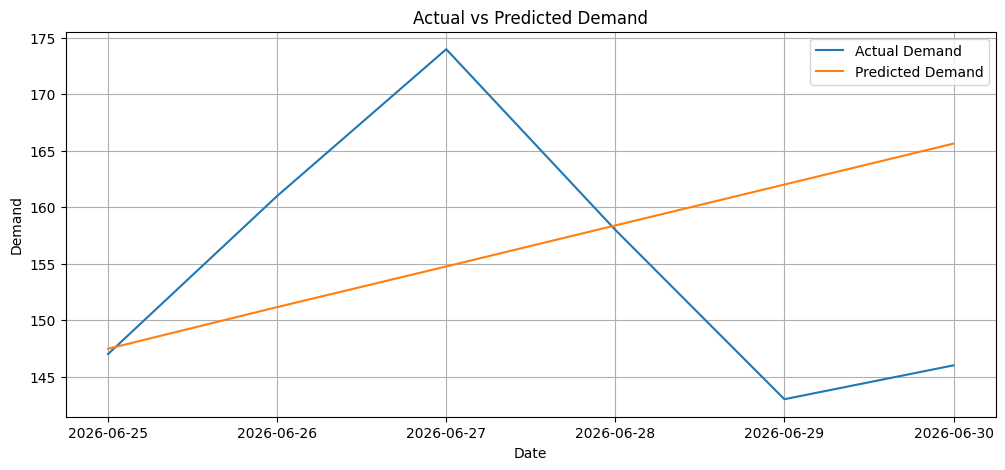

✅ Actual vs Predicted graph created successfully.


In [ ]:
# Actual vs Predicted Demand

try:
    if "test" not in globals():
        print("❌ Test data not found.")
    elif "predictions" not in globals():
        print("❌ Predictions not found.")
    else:
        plt.figure(figsize=(12, 5))

        plt.plot(test.index, test.values, label="Actual Demand")
        plt.plot(predictions.index, predictions.values, label="Predicted Demand")

        plt.title("Actual vs Predicted Demand")
        plt.xlabel("Date")
        plt.ylabel("Demand")
        plt.legend()
        plt.grid(True)

        plt.show()

        print("✅ Actual vs Predicted graph created successfully.")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

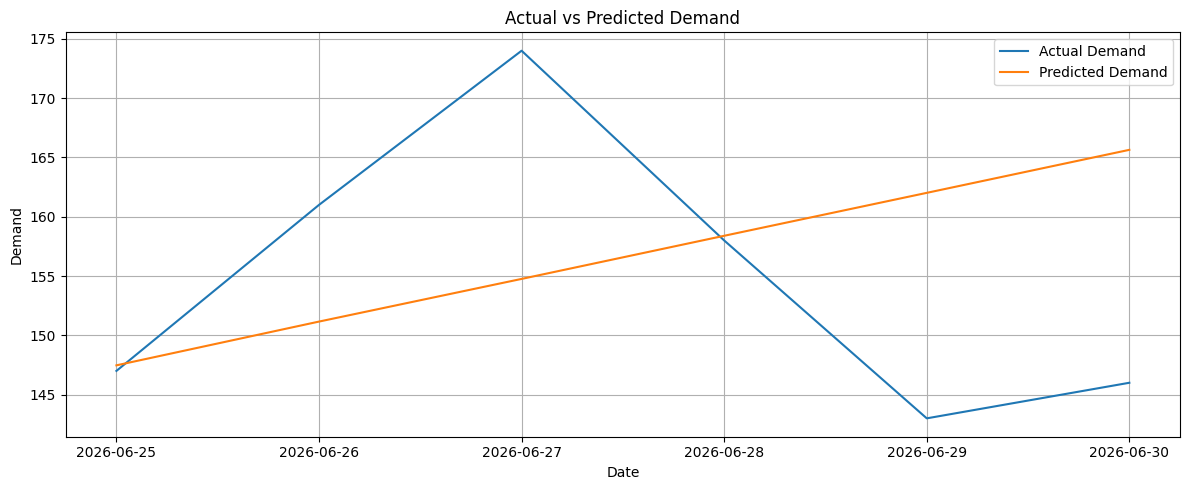

✅ Graph saved as actual_vs_predicted.png


In [ ]:
# Save Actual vs Predicted graph as PNG

try:
    if "test" not in globals() or "predictions" not in globals():
        print("❌ Test data or predictions not found.")
    else:
        plt.figure(figsize=(12, 5))

        plt.plot(test.index, test.values, label="Actual Demand")
        plt.plot(predictions.index, predictions.values, label="Predicted Demand")

        plt.title("Actual vs Predicted Demand")
        plt.xlabel("Date")
        plt.ylabel("Demand")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()

        # Save graph
        plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")

        plt.show()

        print("✅ Graph saved as actual_vs_predicted.png")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

In [ ]:
# Model Evaluation - MAPE and RMSE

try:
    import numpy as np
    from sklearn.metrics import mean_squared_error

    if "test" not in globals():
        print("❌ Test data not found.")

    elif "predictions" not in globals():
        print("❌ Predictions not found.")

    else:
        actual = pd.to_numeric(test, errors="coerce")
        predicted = pd.to_numeric(predictions, errors="coerce")

        # Remove invalid values
        valid = actual.notna() & predicted.notna()

        actual = actual[valid]
        predicted = predicted[valid]

        if len(actual) == 0:
            print("❌ No valid values available for evaluation.")

        else:
            # MAPE
            non_zero = actual != 0

            if non_zero.sum() == 0:
                print("❌ MAPE cannot be calculated because all actual values are zero.")
            else:
                mape = np.mean(
                    np.abs(
                        (actual[non_zero] - predicted[non_zero])
                        / actual[non_zero]
                    )
                ) * 100

                # RMSE
                rmse = np.sqrt(
                    mean_squared_error(actual, predicted)
                )

                print("✅ Model Evaluation Completed")
                print("--------------------------------")
                print(f"MAPE : {mape:.2f}%")
                print(f"RMSE : {rmse:.2f}")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ Model Evaluation Completed
--------------------------------
MAPE : 7.41%
RMSE : 14.23


In [ ]:
# Future Demand Forecast

try:
    if "arima_model" not in globals():
        print("❌ ARIMA model not found.")
        print("Please run the ARIMA model cell first.")

    else:
        # Forecast next 30 observations
        forecast_steps = 30

        future_forecast = arima_model.forecast(steps=forecast_steps)

        print("✅ 30-day future forecast generated successfully!")
        print("\nForecast values:\n")
        print(future_forecast)

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ 30-day future forecast generated successfully!

Forecast values:

2026-06-25    147.469242
2026-06-26    151.159280
2026-06-27    154.757466
2026-06-28    158.393863
2026-06-29    162.014364
2026-06-30    165.641478
2026-07-01    169.265841
2026-07-02    172.891348
2026-07-03    176.516379
2026-07-04    180.141608
2026-07-05    183.766755
2026-07-06    187.391936
2026-07-07    191.017103
2026-07-08    194.642276
2026-07-09    198.267446
2026-07-10    201.892618
2026-07-11    205.517789
2026-07-12    209.142960
2026-07-13    212.768131
2026-07-14    216.393302
2026-07-15    220.018473
2026-07-16    223.643644
2026-07-17    227.268815
2026-07-18    230.893986
2026-07-19    234.519157
2026-07-20    238.144328
2026-07-21    241.769499
2026-07-22    245.394670
2026-07-23    249.019841
2026-07-24    252.645012
Freq: D, Name: predicted_mean, dtype: float64


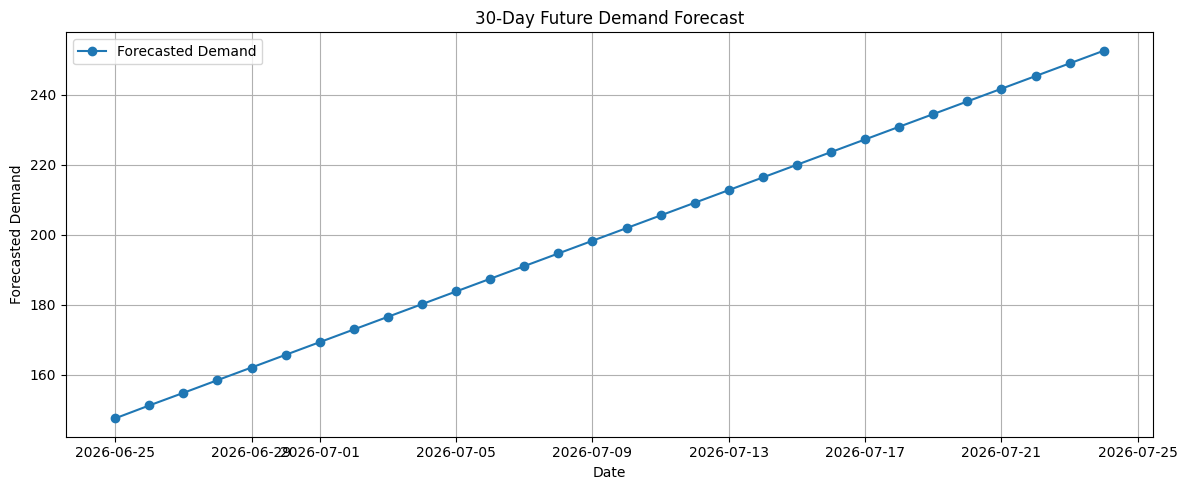

✅ Future forecast graph created successfully!
✅ Saved as future_demand_forecast.png


In [ ]:
# Future Forecast Graph

try:
    if "future_forecast" not in globals():
        print("❌ Future forecast not found.")
        print("Please run the 30-day forecast cell first.")

    else:
        plt.figure(figsize=(12, 5))

        plt.plot(
            future_forecast.index,
            future_forecast.values,
            marker="o",
            label="Forecasted Demand"
        )

        plt.title("30-Day Future Demand Forecast")
        plt.xlabel("Date")
        plt.ylabel("Forecasted Demand")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()

        # Save graph
        plt.savefig(
            "future_demand_forecast.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print("✅ Future forecast graph created successfully!")
        print("✅ Saved as future_demand_forecast.png")

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

In [ ]:
# Display future forecast as a clean table

try:
    if "future_forecast" not in globals():
        print("❌ Future forecast not found.")
    else:
        forecast_table = future_forecast.reset_index()
        forecast_table.columns = ["Date", "Forecasted Demand"]

        print("✅ Future Forecast Table")
        print(forecast_table.to_string(index=False))

except Exception as e:
    print("❌ Error:", type(e).__name__, "-", e)

✅ Future Forecast Table
      Date  Forecasted Demand
2026-06-25         147.469242
2026-06-26         151.159280
2026-06-27         154.757466
2026-06-28         158.393863
2026-06-29         162.014364
2026-06-30         165.641478
2026-07-01         169.265841
2026-07-02         172.891348
2026-07-03         176.516379
2026-07-04         180.141608
2026-07-05         183.766755
2026-07-06         187.391936
2026-07-07         191.017103
2026-07-08         194.642276
2026-07-09         198.267446
2026-07-10         201.892618
2026-07-11         205.517789
2026-07-12         209.142960
2026-07-13         212.768131
2026-07-14         216.393302
2026-07-15         220.018473
2026-07-16         223.643644
2026-07-17         227.268815
2026-07-18         230.893986
2026-07-19         234.519157
2026-07-20         238.144328
2026-07-21         241.769499
2026-07-22         245.394670
2026-07-23         249.019841
2026-07-24         252.645012
